<a href="https://colab.research.google.com/github/SaiHarshaPapisetti/toxic-language-detection/blob/main/35054998_toxic_language_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Toxic Language Detection — End-to-End Pipeline
Run this top-to-bottom in Google Colab (T4 GPU runtime: Runtime > Change runtime type > T4 GPU).

**Before you start:** upload your `kaggle.json` API token (Kaggle account > Settings > Create New API Token), or manually upload the Jigsaw CSV files to `/content/`.

## 1. Setup

In [ ]:
!pip install -q kaggle transformers datasets accelerate scikit-learn pandas matplotlib
import pandas as pd, numpy as np, re, time, json
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score
np.random.seed(42)

## 2. Download and load the Jigsaw dataset

In [ ]:
# Option A: Kaggle API (uncomment and upload kaggle.json first)
from google.colab import files
files.upload()  # select kaggle.json
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d julian3833/jigsaw-toxic-comment-classification-challenge -p /content/data --unzip

# Option B: manually upload train.csv to /content/data/ then point to it below
DATA_PATH = "/content/data/train.csv"
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

Saving archive.zip to archive (1).zip
cp: cannot stat 'kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/julian3833/jigsaw-toxic-comment-classification-challenge
License(s): CC0-1.0
100% 53.4M/53.4M [00:00<00:00, 130MB/s]

(159571, 8)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


## 3. Build binary toxic label and apply the 150-word long-sequence filter

In [ ]:
toxic_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
df['label'] = (df[toxic_cols].sum(axis=1) > 0).astype(int)
df['word_count'] = df['comment_text'].str.split().str.len()

print('Full dataset:', len(df), 'records |', f"{df['label'].mean()*100:.2f}% toxic")

long_df = df[df['word_count'] >= 150].reset_index(drop=True)
print('After 150+ word filter:', len(long_df), 'records |', f"{long_df['label'].mean()*100:.2f}% toxic")
long_df.to_csv('/content/filtered_long_sequence.csv', index=False)

Full dataset: 159571 records | 10.17% toxic
After 150+ word filter: 16353 records | 6.29% toxic


## 4. Preprocessing — classical ML stream (TF-IDF) + 80/10/10 split
The split below is shared: the same train/val/test row split is used for BOTH the classical models (Section 5) and the transformer (Section 6), so every model is compared on an identical, untouched test set.

In [ ]:
def clean_classical(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

long_df['clean_text'] = long_df['comment_text'].apply(clean_classical)

# --- 80 / 10 / 10 split (train / validation / test) ---
# Step 1: carve off 10% as the final, untouched TEST set
X_temp, X_test, y_temp, y_test = train_test_split(
    long_df['clean_text'], long_df['label'], test_size=0.10,
    random_state=42, stratify=long_df['label'])

# Step 2: split the remaining 90% into TRAIN (80% of original) and VAL (10% of original)
# 0.10 / 0.90 = 0.1111... -> this gives exactly 10% of the ORIGINAL data as validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1111111,
    random_state=42, stratify=y_temp)

print(f"Train: {len(X_train)} ({len(X_train)/len(long_df)*100:.1f}%)")
print(f"Val:   {len(X_val)} ({len(X_val)/len(long_df)*100:.1f}%)")
print(f"Test:  {len(X_test)} ({len(X_test)/len(long_df)*100:.1f}%)")
for name, y in [('train', y_train), ('val', y_val), ('test', y_test)]:
    print(name, 'toxic rate:', round(y.mean(), 4))

# TF-IDF: fit on TRAIN ONLY, transform train/val/test
vectorizer = TfidfVectorizer(max_features=20000, stop_words='english', ngram_range=(1,2))
Xtr = vectorizer.fit_transform(X_train)
Xval = vectorizer.transform(X_val)
Xte = vectorizer.transform(X_test)
print(Xtr.shape, Xval.shape, Xte.shape)

Train: 13081 (80.0%)
Val:   1636 (10.0%)
Test:  1636 (10.0%)
train toxic rate: 0.0629
val toxic rate: 0.063
test toxic rate: 0.063
(13081, 20000) (1636, 20000) (1636, 20000)


## 5. Train and evaluate classical baselines
Trained on the 80% train split, final metrics reported on the untouched 10% test split (Xte/y_test). Note: these numbers will differ slightly from any previous run, since the split is now 80/10/10 instead of 80/20 — the test set is smaller.

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Linear SVM': LinearSVC(class_weight='balanced'),
    'Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1),
}

results = []
for name, model in models.items():
    t0 = time.time()
    model.fit(Xtr, y_train)
    train_time = time.time() - t0
    t0 = time.time()
    preds = model.predict(Xte)
    infer_time = time.time() - t0
    scores = model.predict_proba(Xte)[:,1] if hasattr(model, 'predict_proba') else model.decision_function(Xte)
    results.append({
        'Model': name,
        'F1': round(f1_score(y_test, preds), 3),
        'ROC-AUC': round(roc_auc_score(y_test, scores), 3),
        'Precision': round(precision_score(y_test, preds), 3),
        'Recall': round(recall_score(y_test, preds), 3),
        'Train Time (s)': round(train_time, 3),
        'Inference Time (s)': round(infer_time, 4),
    })

classical_results_df = pd.DataFrame(results)
classical_results_df.to_csv('/content/classical_results.csv', index=False)
classical_results_df

,Model,F1,ROC-AUC,Precision,Recall,Train Time (s),Inference Time (s)
0,Logistic Regression,0.597,0.948,0.510,0.718,1.364,0.0031
1,Linear SVM,0.642,0.945,0.624,0.660,0.664,0.0011
2,Naive Bayes,0.306,0.888,0.905,0.184,0.017,0.0023
3,Random Forest,0.561,0.945,0.815,0.427,40.495,0.2232


## 6. Fine-tune DistilBERT / BERT-base (transformer stream)
Run DistilBERT first (faster) to validate the training loop before committing GPU time to full BERT.

**Key fix:** training now validates on the VAL set (`val_ds`) for checkpoint selection — never the test set. The test set is only touched once, in Section 6.1, after training is fully finished.

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

MODEL_NAME = 'distilbert-base-uncased'  # switch to 'bert-base-uncased' for the full BERT run

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_ds = Dataset.from_pandas(pd.DataFrame({'text': X_train, 'label': y_train}).reset_index(drop=True))
val_ds   = Dataset.from_pandas(pd.DataFrame({'text': X_val,   'label': y_val}).reset_index(drop=True))
test_ds  = Dataset.from_pandas(pd.DataFrame({'text': X_test,  'label': y_test}).reset_index(drop=True))

def tokenize_fn(batch):
    return tokenizer(batch['text'], truncation=True, padding='max_length', max_length=256)

train_ds = train_ds.map(tokenize_fn, batched=True)
val_ds   = val_ds.map(tokenize_fn, batched=True)
test_ds  = test_ds.map(tokenize_fn, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

training_args = TrainingArguments(
    output_dir='/content/checkpoints',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=4,
    save_strategy='epoch',
    eval_strategy='epoch',
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    fp16=True,
    report_to='none',
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    probs = torch.softmax(torch.tensor(logits), dim=1)[:,1].numpy()
    return {
        'f1': f1_score(labels, preds),
        'roc_auc': roc_auc_score(labels, probs),
        'precision': precision_score(labels, preds),
        'recall': recall_score(labels, preds),
    }

trainer = Trainer(
    model=model, args=training_args,
    train_dataset=train_ds, eval_dataset=val_ds,   # <-- VAL, not test: fixes the leakage
    compute_metrics=compute_metrics,
)

t0 = time.time()
trainer.train()
transformer_train_time = time.time() - t0
print('Training time (s):', transformer_train_time)
print('Peak VRAM (MB):', torch.cuda.max_memory_allocated()/1e6 if torch.cuda.is_available() else 'N/A (CPU)')

Map:   0%|          | 0/13081 [00:00<?, ? examples/s]

Map:   0%|          | 0/1636 [00:00<?, ? examples/s]

Map:   0%|          | 0/1636 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Precision,Recall
1,0.456634,0.102410,0.724324,0.954360,0.817073,0.650485
2,0.400136,0.123130,0.706522,0.954667,0.802469,0.631068
3,0.140414,0.158359,0.721951,0.955937,0.725490,0.718447


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training time (s): 309.68952918052673
Peak VRAM (MB): 1659.01824


### 6.1 Final test-set evaluation (run once)

In [ ]:
# --- 6.1 Final test-set evaluation (run ONCE, after training is fully finished) ---
# This is the only place the test set is used for the transformer — never during training.
t0 = time.time()
test_predictions = trainer.predict(test_ds)
transformer_inference_time = time.time() - t0

logits = test_predictions.predictions
labels = test_predictions.label_ids
preds = np.argmax(logits, axis=1)
probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()

test_metrics = {
    'f1': f1_score(labels, preds),
    'roc_auc': roc_auc_score(labels, probs),
    'precision': precision_score(labels, preds),
    'recall': recall_score(labels, preds),
}
print('Final TEST metrics (unbiased — never seen during training):', test_metrics)
print(f'Inference time (s) over {len(test_ds)} test comments:', round(transformer_inference_time, 4))


Final TEST metrics (unbiased — never seen during training): {'f1': 0.7292817679558011, 'roc_auc': np.float64(0.9635463175827587), 'precision': 0.8461538461538461, 'recall': 0.6407766990291263}
Inference time (s) over 1636 test comments: 3.4648


## 7. Master comparison table (classical + transformer)
Uses the unbiased `test_metrics` + `transformer_inference_time` from Section 6.1 — not `trainer.evaluate()`, which would report validation-set numbers.

In [ ]:
transformer_row = {
    'Model': MODEL_NAME,
    'F1': round(test_metrics['f1'], 3),
    'ROC-AUC': round(test_metrics['roc_auc'], 3),
    'Precision': round(test_metrics['precision'], 3),
    'Recall': round(test_metrics['recall'], 3),
    'Train Time (s)': round(transformer_train_time, 3),
    'Inference Time (s)': round(transformer_inference_time, 4),
}
master_df = pd.concat([classical_results_df, pd.DataFrame([transformer_row])], ignore_index=True)
master_df.to_csv('/content/master_comparison.csv', index=False)
master_df

,Model,F1,ROC-AUC,Precision,Recall,Train Time (s),Inference Time (s)
0,Logistic Regression,0.597,0.948,0.510,0.718,1.364,0.0031
1,Linear SVM,0.642,0.945,0.624,0.660,0.664,0.0011
2,Naive Bayes,0.306,0.888,0.905,0.184,0.017,0.0023
3,Random Forest,0.561,0.945,0.815,0.427,40.495,0.2232
4,distilbert-base-uncased,0.729,0.964,0.846,0.641,309.690,3.4648


## 8. Chapter 4 chart

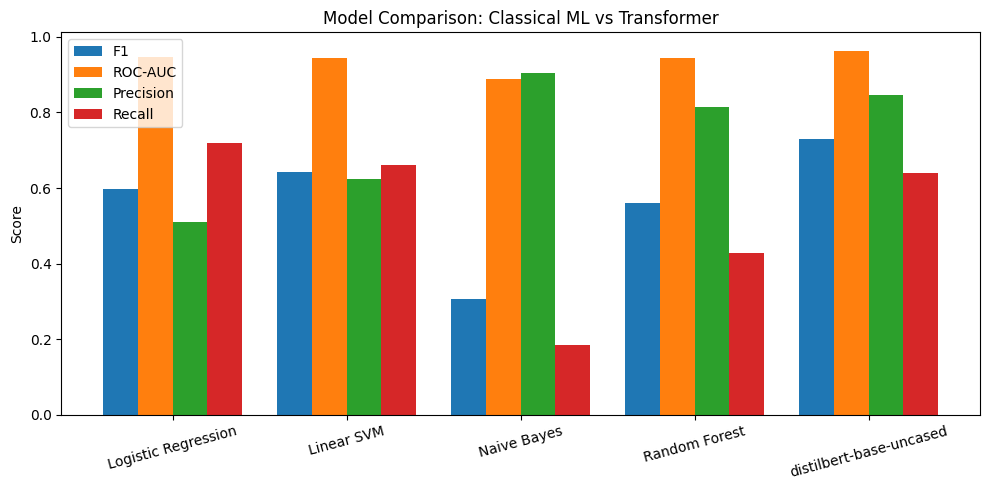

In [ ]:
metrics_to_plot = ['F1', 'ROC-AUC', 'Precision', 'Recall']
x = np.arange(len(master_df)); width = 0.2
fig, ax = plt.subplots(figsize=(10,5))
for i, m in enumerate(metrics_to_plot):
    ax.bar(x + i*width, master_df[m], width, label=m)
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(master_df['Model'], rotation=15)
ax.set_ylabel('Score'); ax.legend(); ax.set_title('Model Comparison: Classical ML vs Transformer')
plt.tight_layout(); plt.savefig('/content/model_comparison_real.png', dpi=200)
plt.show()

## 9. Fairness audit (no human participants — dataset-level subgroup analysis)
Uses dialectal proxy markers (Blodgett et al., 2020) to partition the TEST set and compares the transformer's F1/precision/recall across subgroups. Reuses the `preds`/`labels` already computed in Section 6.1 — no extra inference needed.

In [ ]:
# Simple illustrative proxy marker list — replace/extend with validated AAVE/SAE marker lists from your literature review
aave_markers = ["finna", "tryna", "y'all", "ain't", "gon"]

# test_ds still has the original 'text' column alongside the tokenized fields, in the SAME order as
# `preds`/`labels`/`probs` from Section 6.1 — so we can reuse those directly, no re-prediction needed.
test_texts = pd.Series(test_ds['text'])
has_marker = test_texts.str.lower().apply(lambda t: any(m in t for m in aave_markers))

fairness_rows = []
overall_f1 = f1_score(labels, preds)
fairness_rows.append({
    'Subgroup': 'Overall (all test comments)',
    'N': len(labels),
    'F1-score': round(overall_f1, 4),
    'Precision': round(precision_score(labels, preds), 4),
    'Recall': round(recall_score(labels, preds), 4),
})

for group_name, mask in [('Marker present', has_marker.values), ('Marker absent', ~has_marker.values)]:
    n = mask.sum()
    if n >= 20:   # skip subgroups too small to report reliably
        fairness_rows.append({
            'Subgroup': group_name,
            'N': int(n),
            'F1-score': round(f1_score(labels[mask], preds[mask]), 4),
            'Precision': round(precision_score(labels[mask], preds[mask]), 4),
            'Recall': round(recall_score(labels[mask], preds[mask]), 4),
        })
    else:
        fairness_rows.append({'Subgroup': group_name, 'N': int(n), 'F1-score': 'insufficient data (<20)', 'Precision': '-', 'Recall': '-'})

fairness_df = pd.DataFrame(fairness_rows)
fairness_df.to_csv('/content/fairness_audit_results.csv', index=False)
fairness_df

,Subgroup,N,F1-score,Precision,Recall
0,Overall (all test comments),1636,0.7293,0.8462,0.6408
1,Marker present,105,0.3158,0.5000,0.2308
2,Marker absent,1531,0.7778,0.8750,0.7000


## 10. Figure 4.2 — Inference Latency by Model (log scale)
Uses `master_df` from Section 7 directly — no new inference or data collection needed. Plotted on a log scale because DistilBERT's latency is ~3 orders of magnitude higher than the classical models', which would be unreadable on a linear axis.

/tmp/ipykernel_6796/2036564268.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models_list, rotation=15, ha='right')


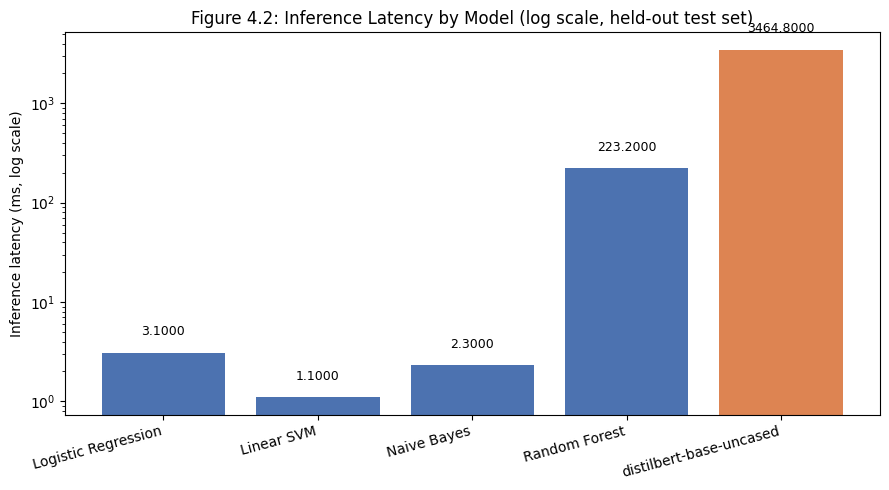

In [ ]:
latency_ms = (master_df['Inference Time (s)'] * 1000).values
models_list = master_df['Model'].tolist()

# Highlight the transformer (always the last row, since master_df = classical rows + transformer_row)
colors = ['#4C72B0'] * (len(models_list) - 1) + ['#DD8452']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(models_list, latency_ms, color=colors)
ax.set_yscale('log')
ax.set_ylabel('Inference latency (ms, log scale)')
ax.set_title('Figure 4.2: Inference Latency by Model (log scale, held-out test set)')
ax.set_xticklabels(models_list, rotation=15, ha='right')

for b, v in zip(bars, latency_ms):
    ax.text(b.get_x() + b.get_width() / 2, v * 1.4, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/content/figure_4_2_latency_log.png', dpi=200)
plt.show()


## 11. Figure 4.3 — DistilBERT F1-score by Fairness Subgroup
Uses `fairness_df` from Section 9 directly. Subgroups with fewer than 20 records are excluded from the plot (they're already flagged as `'insufficient data (<20)'` in the table and shouldn't be charted as if they were reliable estimates).

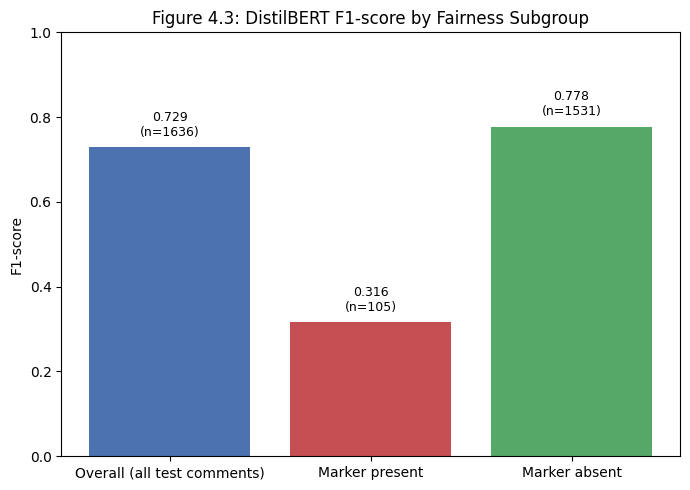

In [ ]:
plot_df = fairness_df[fairness_df['F1-score'] != 'insufficient data (<20)'].copy()
plot_df['F1-score'] = plot_df['F1-score'].astype(float)

palette = ['#4C72B0', '#C44E52', '#55A868']
colors = palette[:len(plot_df)]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(plot_df['Subgroup'], plot_df['F1-score'], color=colors)
ax.set_ylabel('F1-score')
ax.set_ylim(0, 1.0)
ax.set_title('Figure 4.3: DistilBERT F1-score by Fairness Subgroup')

for b, v, n in zip(bars, plot_df['F1-score'], plot_df['N']):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f'{v:.3f}\n(n={n})', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/content/figure_4_3_fairness_subgroup.png', dpi=200)
plt.show()


## 12. Figure — BERT-base vs. DistilBERT Architecture Comparison
**Important — read before using this cell:** BERT-base was **not** fine-tuned or evaluated anywhere in this notebook (see your report's Limitations, Section 5.5) — only DistilBERT was actually trained. The numbers below are **published architectural specifications and the distillation benchmark reported in the original DistilBERT paper** (Sanh, V., Debut, L., Chaumond, J., & Wolf, T. (2019). *DistilBERT, a distilled version of BERT: smaller, faster, cheaper and lighter*. arXiv:1910.01108), not experimental results from your own test set. If your professor asks how you got this, the honest answer is: these three values are cited facts from the DistilBERT paper, hard-coded here for plotting — they are not computed from `master_df` or any variable in this notebook, because no BERT-base run exists to compute them from.

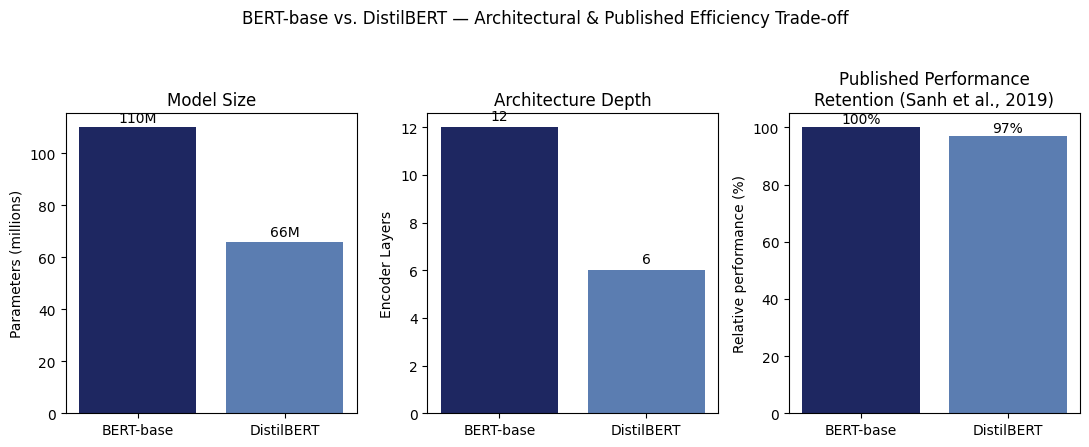

In [ ]:
# Published values — NOT computed from this notebook's own experiments.
# Source: Sanh et al. (2019), DistilBERT paper (arXiv:1910.01108). Cite this source wherever
# this figure is used.
model_names = ['BERT-base', 'DistilBERT']
params_millions = [110, 66]                 # total parameter count (millions)
layers = [12, 6]                             # number of transformer encoder layers
performance_retention_pct = [100, 97]        # DistilBERT retains ~97% of BERT's GLUE performance

fig, axes = plt.subplots(1, 3, figsize=(11, 4.3))
bar_colors = ['#1E2761', '#5B7DB1']

axes[0].bar(model_names, params_millions, color=bar_colors)
axes[0].set_ylabel('Parameters (millions)')
axes[0].set_title('Model Size')
for i, v in enumerate(params_millions):
    axes[0].text(i, v + 2, f'{v}M', ha='center')

axes[1].bar(model_names, layers, color=bar_colors)
axes[1].set_ylabel('Encoder Layers')
axes[1].set_title('Architecture Depth')
for i, v in enumerate(layers):
    axes[1].text(i, v + 0.3, str(v), ha='center')

axes[2].bar(model_names, performance_retention_pct, color=bar_colors)
axes[2].set_ylabel('Relative performance (%)')
axes[2].set_title('Published Performance\nRetention (Sanh et al., 2019)')
for i, v in enumerate(performance_retention_pct):
    axes[2].text(i, v + 1.5, f'{v}%', ha='center')

fig.suptitle('BERT-base vs. DistilBERT — Architectural & Published Efficiency Trade-off', y=1.03)
plt.tight_layout()
plt.savefig('/content/figure_bert_vs_distilbert.png', dpi=200, bbox_inches='tight')
plt.show()
